# VEEV Variant Analysis
Analyze annotated variants from both iVar and LoFreq variant callers across different time points (1, 3, 5 DPI).

## Data Overview
- **LoFreq**: Annotated VCF files from LoFreq variant calling
- **iVar**: Annotated VCF files converted from iVar TSV format
- **Time points**: 1, 3, 5 days post-infection (DPI)
- **Replicates**: 4 biological replicates per time point

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import glob
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pysam

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


Define data loading functions

In [4]:
def parse_bcsq(bcsq_field):
    """
    Parse BCSQ annotation field into individual components.
    BCSQ format: consequence|gene|transcript|biotype|strand|amino_acid_change|dna_change
    """
    if bcsq_field is None:
        return {
            'consequence': None,
            'gene': None,
            'transcript': None,
            'biotype': None,
            'strand': None,
            'amino_acid_change': None,
            'dna_change': None
        }
    
    # Handle both tuple format (LoFreq) and string format (iVar)
    bcsq_str = bcsq_field
    if isinstance(bcsq_field, tuple):
        if len(bcsq_field) > 0:
            bcsq_str = bcsq_field[0]
        else:
            bcsq_str = None
    
    if bcsq_str is None or bcsq_str == '' or str(bcsq_str).startswith('@'):
        return {
            'consequence': None,
            'gene': None,
            'transcript': None,
            'biotype': None,
            'strand': None,
            'amino_acid_change': None,
            'dna_change': None
        }
    
    # Split by pipe
    parts = str(bcsq_str).split('|')
    
    return {
        'consequence': parts[0] if len(parts) > 0 else None,
        'gene': parts[1] if len(parts) > 1 else None,
        'transcript': parts[2] if len(parts) > 2 else None,
        'biotype': parts[3] if len(parts) > 3 else None,
        'strand': parts[4] if len(parts) > 4 else None,
        'amino_acid_change': parts[5] if len(parts) > 5 else None,
        'dna_change': parts[6] if len(parts) > 6 else None
    }

def parse_vcf_file(vcf_path):
    """
    Parse VCF file using pysam with cleaner column names and parsed BCSQ.
    Handle problematic VCF headers more robustly.
    """
    try:
        variants = []
        vcf_in = pysam.VariantFile(vcf_path)
        
        for record in vcf_in:
            # Extract ALT allele properly
            alt_allele = '.'
            if record.alts:
                alt_allele = str(record.alts[0])
                
            # Extract INFO fields with proper handling of missing values
            variant_data = {
                'CHROM': record.chrom,
                'POS': record.pos,
                'REF': record.ref,
                'ALT': alt_allele,
                'QUAL': record.qual if record.qual is not None else '.',
                'FILTER': ','.join(record.filter) if record.filter else 'PASS',
                'DP': record.info.get('DP', None),
                'AF': record.info.get('AF', None), 
                'SB': record.info.get('SB', None),
                'DP4': record.info.get('DP4', None),
                'BCSQ_raw': record.info.get('BCSQ', None)
            }
            
            # Parse BCSQ into separate columns
            bcsq_parsed = parse_bcsq(variant_data['BCSQ_raw'])
            variant_data.update(bcsq_parsed)
            
            variants.append(variant_data)
        
        vcf_in.close()
        return pd.DataFrame(variants) if variants else pd.DataFrame()
        
    except Exception as e:
        print(f"Error parsing {vcf_path}: {str(e)}")
        # alternative approach for problematic files
        try:
            return parse_vcf_manually(vcf_path)
        except:
            return pd.DataFrame()

def parse_vcf_manually(vcf_path):
    """
    Fallback manual parsing for problematic VCF files.
    NOW INCLUDES iVar frequency extraction from FORMAT field.
    """
    variants = []
    with open(vcf_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            
            parts = line.split('\t')
            if len(parts) >= 8:
                variant_data = {
                    'CHROM': parts[0],
                    'POS': int(parts[1]),
                    'REF': parts[3],
                    'ALT': parts[4],
                    'QUAL': parts[5] if parts[5] != '.' else None,
                    'FILTER': parts[6] if parts[6] != '.' else 'PASS',
                    'DP': None,
                    'AF': None,
                    'SB': None,
                    'DP4': None,
                    'BCSQ_raw': None
                }
                
                # Parse INFO field
                info_parts = parts[7].split(';')
                for info in info_parts:
                    if '=' in info:
                        key, value = info.split('=', 1)
                        if key == 'DP':
                            try:
                                variant_data['DP'] = int(value)
                            except:
                                pass
                        elif key == 'BCSQ':
                            variant_data['BCSQ_raw'] = value
                
                # Parse FORMAT field for iVar ALT_FREQ (if present)
                if len(parts) >= 10:  # Has FORMAT and sample columns
                    format_field = parts[8]
                    sample_data = parts[9]
                    format_keys = format_field.split(':')
                    sample_values = sample_data.split(':')
                    
                    # Extract ALT_FREQ if available
                    if 'ALT_FREQ' in format_keys and len(sample_values) > format_keys.index('ALT_FREQ'):
                        alt_freq_idx = format_keys.index('ALT_FREQ')
                        try:
                            variant_data['AF'] = float(sample_values[alt_freq_idx])
                        except:
                            variant_data['AF'] = None
                
                # Parse BCSQ into separate columns
                bcsq_parsed = parse_bcsq(variant_data['BCSQ_raw'])
                variant_data.update(bcsq_parsed)
                            
                variants.append(variant_data)
    
    return pd.DataFrame(variants) if variants else pd.DataFrame()

def extract_sample_info(filename):
    """Extract sample info from filename."""
    basename = os.path.splitext(os.path.basename(filename))[0]
    match = re.match(r'INH_(\d+)_DPI_R(\d+)_([A-Z]\d+)', basename)
    
    if match:
        return {
            'sample_id': basename,
            'dpi': int(match.group(1)),
            'replicate': int(match.group(2)),
            'plate': match.group(3)
        }
    return {'sample_id': basename, 'dpi': None, 'replicate': None, 'plate': None}



Load Lofreq data

In [5]:
# Load LoFreq variants
print("Loading LoFreq variants...")
# Check current working directory


# Look for VCF files in the LoFreq subdirectory
lofreq_files = glob.glob("../Annotated_variants/LoFreq/*.vcf")
if not lofreq_files:
    # If not found, try looking in parent directory structure
    lofreq_files = glob.glob("../../Annotated_variants/LoFreq/*.vcf")
if not lofreq_files:
    # Try absolute path
    lofreq_files = glob.glob("/home/jonssonlab/Desktop/Alex/VEEV/044_NH/Variant_discovery_pipeline/Annotated_variants/LoFreq/*.vcf")

print(f"Found {len(lofreq_files)} LoFreq VCF files")
if lofreq_files:
    print("Files found:")
    for f in lofreq_files[:3]:  # Show first 3 files
        print(f"  {f}")
    if len(lofreq_files) > 3:
        print(f"  ... and {len(lofreq_files) - 3} more")

lofreq_data = []
for vcf_file in lofreq_files:
    print(f"  Processing {os.path.basename(vcf_file)}...")
    df = parse_vcf_file(vcf_file)
    
    # Add sample information even for empty files
    sample_info = extract_sample_info(vcf_file)
    
    if not df.empty:
        # Add metadata for files with variants
        for key, value in sample_info.items():
            df[key] = value
        
        # Add variant caller info
        df['variant_caller'] = 'LoFreq'
        df['source_file'] = os.path.basename(vcf_file)
        
        lofreq_data.append(df)
    else:
        # Track empty files for summary
        print(f"    Empty file (no variants) - DPI {sample_info.get('dpi', 'unknown')}")

# Combine all LoFreq data
if lofreq_data:
    lofreq_df = pd.concat(lofreq_data, ignore_index=True)
    print(f"LoFreq DataFrame created with {len(lofreq_df)} variants from {len(lofreq_data)} samples with variants")
else:
    lofreq_df = pd.DataFrame()
    print("No LoFreq variants found")

print(f"LoFreq variants by DPI:")
if not lofreq_df.empty:
    print(lofreq_df.groupby('dpi').size())
    print(f"\nFILTER column values in LoFreq data:")
    print(lofreq_df['FILTER'].value_counts())
else:
    print("No data to display")

Loading LoFreq variants...
Found 9 LoFreq VCF files
Files found:
  ../Annotated_variants/LoFreq/INH_5_DPI_R1_E3_filtered.vcf
  ../Annotated_variants/LoFreq/INH_3_DPI_R3_C3_filtered.vcf
  ../Annotated_variants/LoFreq/INH_3_DPI_R2_B3_filtered.vcf
  ... and 6 more
  Processing INH_5_DPI_R1_E3_filtered.vcf...
  Processing INH_3_DPI_R3_C3_filtered.vcf...
  Processing INH_3_DPI_R2_B3_filtered.vcf...
  Processing INH_5_DPI_R2_F3_filtered.vcf...
  Processing INH_3_DPI_R1_A3_annotated.vcf...
Error parsing ../Annotated_variants/LoFreq/INH_3_DPI_R1_A3_annotated.vcf: invalid file `b'../Annotated_variants/LoFreq/INH_3_DPI_R1_A3_annotated.vcf'` (mode=`b'r'`) - is it VCF/BCF format?
    Empty file (no variants) - DPI 3
  Processing INH_5_DPI_R3_G3_filtered.vcf...
  Processing INH_5_DPI_R4_H3_filtered.vcf...
  Processing INH_3_DPI_R1_A3_filtered.vcf...
  Processing INH_3_DPI_R4_D3_filtered.vcf...
LoFreq DataFrame created with 3166 variants from 8 samples with variants
LoFreq variants by DPI:
dpi
3    

Load Ivar data

In [6]:
# Load iVar variants
print("Loading iVar variants...")

# Look for VCF files in the Ivar subdirectory
ivar_files = glob.glob("../Annotated_variants/Ivar/*.vcf")
if not ivar_files:
    # If not found, try looking in parent directory structure
    ivar_files = glob.glob("../../Annotated_variants/Ivar/*.vcf")
if not ivar_files:
    # Try absolute path
    ivar_files = glob.glob("/home/jonssonlab/Desktop/Alex/VEEV/044_NH/Variant_discovery_pipeline/Annotated_variants/Ivar/*.vcf")

print(f"Found {len(ivar_files)} iVar VCF files")
if ivar_files:
    print("Files found:")
    for f in ivar_files[:3]:  # Show first 3 files
        print(f"  {f}")
    if len(ivar_files) > 3:
        print(f"  ... and {len(ivar_files) - 3} more")

ivar_data = []
for vcf_file in ivar_files:
    print(f"  Processing {os.path.basename(vcf_file)}...")
    df = parse_vcf_file(vcf_file)
    
    # Add sample information even for empty files
    sample_info = extract_sample_info(vcf_file)
    
    if not df.empty:
        # Add metadata for files with variants
        for key, value in sample_info.items():
            df[key] = value
        
        # Add variant caller info
        df['variant_caller'] = 'iVar'
        df['source_file'] = os.path.basename(vcf_file)
        
        ivar_data.append(df)
    else:
        # Track empty files for summary
        print(f"    Empty file (no variants) - DPI {sample_info.get('dpi', 'unknown')}")

# Combine all iVar data
if ivar_data:
    ivar_df = pd.concat(ivar_data, ignore_index=True)
    print(f"iVar DataFrame created with {len(ivar_df)} variants from {len(ivar_data)} samples with variants")
else:
    ivar_df = pd.DataFrame()
    print("No iVar variants found")

print(f"iVar variants by DPI:")
if not ivar_df.empty:
    print(ivar_df.groupby('dpi').size())
    print(f"\nFILTER column values in iVar data:")
    print(ivar_df['FILTER'].value_counts())
else:
    print("No data to display")

Loading iVar variants...
Found 9 iVar VCF files
Files found:
  ../Annotated_variants/Ivar/INH_5_DPI_R3_G3.vcf
  ../Annotated_variants/Ivar/INH_3_DPI_R3_C3.vcf
  ../Annotated_variants/Ivar/INH_3_DPI_R2_B3.vcf
  ... and 6 more
  Processing INH_5_DPI_R3_G3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_5_DPI_R3_G3.vcf: Invalid header
  Processing INH_3_DPI_R3_C3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_3_DPI_R3_C3.vcf: Invalid header
  Processing INH_3_DPI_R2_B3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_3_DPI_R2_B3.vcf: Invalid header
  Processing INH_3_DPI_R4_D3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_3_DPI_R4_D3.vcf: Invalid header
  Processing INH_3_DPI_R1_A3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_3_DPI_R1_A3.vcf: Invalid header
  Processing INH_5_DPI_R2_F3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_5_DPI_R2_F3.vcf: Invalid header
  Processing INH_5_DPI_R1_E3.vcf...
Error parsing ../Annotated_variants/Ivar/INH_5_DPI_R1_E3.vcf:

Inspect data

In [7]:
# Summary of loaded data
print("="*60)
print("VARIANT LOADING SUMMARY")
print("="*60)

print(f"LoFreq variants: {len(lofreq_df) if not lofreq_df.empty else 0}")
print(f"iVar variants: {len(ivar_df) if not ivar_df.empty else 0}")
print(f"Total variants: {(len(lofreq_df) if not lofreq_df.empty else 0) + (len(ivar_df) if not ivar_df.empty else 0)}")

print("\nBreakdown by DPI and variant caller:")
if not lofreq_df.empty or not ivar_df.empty:
    # Combine for summary
    all_variants = []
    if not lofreq_df.empty:
        all_variants.append(lofreq_df[['dpi', 'variant_caller', 'sample_id']].copy())
    if not ivar_df.empty:
        all_variants.append(ivar_df[['dpi', 'variant_caller', 'sample_id']].copy())
    
    if all_variants:
        combined_summary = pd.concat(all_variants, ignore_index=True)
        summary_table = combined_summary.groupby(['dpi', 'variant_caller']).size().unstack(fill_value=0)
        print(summary_table)
        
        print("\nSamples processed:")
        sample_count = combined_summary.groupby(['dpi', 'variant_caller'])['sample_id'].nunique().unstack(fill_value=0)
        print(sample_count)
else:
    print("No variants loaded")

print("\n" + "="*60)

VARIANT LOADING SUMMARY
LoFreq variants: 3166
iVar variants: 2837
Total variants: 6003

Breakdown by DPI and variant caller:
variant_caller  LoFreq  iVar
dpi                         
3                 1319  1211
5                 1847  1626

Samples processed:
variant_caller  LoFreq  iVar
dpi                         
3                    4     4
5                    4     4



# Filter Variants

## Data Structure Overview
Now that we've loaded the data, let's examine the structure of our DataFrames to understand what information is available for analysis.

In [8]:
# Show lofreq df preview
lofreq_df.head()

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,AF,SB,DP4,...,biotype,strand,amino_acid_change,dna_change,sample_id,dpi,replicate,plate,variant_caller,source_file
0,VEEV_INH,38,A,G,119.0,PASS,6923,0.002311,2,"(5239, 1666, 11, 5)",...,None,None,None,None,INH_5_DPI_R1_E3_filtered,5,1,E3,LoFreq,INH_5_DPI_R1_E3_filtered.vcf
1,VEEV_INH,101,A,G,70.0,PASS,12068,0.001243,2,"(7586, 4435, 11, 4)",...,protein_coding,+,19Q,101A>G,INH_5_DPI_R1_E3_filtered,5,1,E3,LoFreq,INH_5_DPI_R1_E3_filtered.vcf
2,VEEV_INH,147,A,G,291.0,PASS,14549,0.002612,4,"(8568, 5925, 21, 20)",...,protein_coding,+,35N>35D,147A>G,INH_5_DPI_R1_E3_filtered,5,1,E3,LoFreq,INH_5_DPI_R1_E3_filtered.vcf
3,VEEV_INH,245,G,A,376.0,PASS,10384,0.004141,12,"(4094, 6229, 11, 32)",...,protein_coding,+,67A,245G>A,INH_5_DPI_R1_E3_filtered,5,1,E3,LoFreq,INH_5_DPI_R1_E3_filtered.vcf
4,VEEV_INH,249,G,A,148.0,PASS,9609,0.002394,25,"(4014, 5564, 3, 21)",...,protein_coding,+,69A>69T,249G>A,INH_5_DPI_R1_E3_filtered,5,1,E3,LoFreq,INH_5_DPI_R1_E3_filtered.vcf


In [9]:
# Show ivar df preview - let's check the current gene annotations AND consequence values
print("Current iVar data preview:")
print("=" * 40)
if not ivar_df.empty:
    print(f"Total iVar variants: {len(ivar_df)}")
    print("\nUnique genes found:")
    print(ivar_df['gene'].value_counts())
    print("\nUnique consequence values in iVar:")
    print(ivar_df['consequence'].value_counts())
    print("\nSample of variants:")
    display(ivar_df[['POS', 'REF', 'ALT', 'gene', 'consequence', 'amino_acid_change', 'AF', 'dpi']].head())
else:
    print("No iVar data loaded yet - running analysis first...")
    
print("\nLoFreq data preview:")
print("=" * 40)
if not lofreq_df.empty:
    print(f"Total LoFreq variants: {len(lofreq_df)}")
    print("\nUnique genes found:")
    print(lofreq_df['gene'].value_counts())
    print("\nUnique consequence values in LoFreq:")
    print(lofreq_df['consequence'].value_counts())
    print("\nSample of variants:")
    display(lofreq_df[['POS', 'REF', 'ALT', 'gene', 'consequence', 'amino_acid_change', 'AF', 'dpi']].head())
else:
    print("No LoFreq data loaded yet")

Current iVar data preview:
Total iVar variants: 2837

Unique genes found:
gene
gene-nsP4      497
gene-nsP2      473
gene-nsP3      441
gene-E1        374
gene-6K        285
gene-nsP1      260
gene-E2        257
gene-Capsid    172
gene-E3         16
Name: count, dtype: int64

Unique consequence values in iVar:
consequence
missense                         1282
synonymous                        711
stop_gained&frameshift            587
frameshift                        167
stop_gained&inframe_insertion      11
stop_gained                        11
inframe_insertion                   6
Name: count, dtype: int64

Sample of variants:


,POS,REF,ALT,gene,consequence,amino_acid_change,AF,dpi
0,1471,A,G,gene-nsP1,missense,476K>476R,0.002447,5
1,1480,C,T,gene-nsP1,missense,479S>479L,0.001137,5
2,1484,T,C,gene-nsP1,synonymous,480P,0.001140,5
3,1493,T,C,gene-nsP1,synonymous,483T,0.001333,5
4,1518,T,-GC,gene-nsP1,stop_gained&frameshift,492CAADEAKEVREAEELRAALPPLAADFEEPTLEADVDLMLQEAG...,0.001160,5



LoFreq data preview:
Total LoFreq variants: 3166

Unique genes found:
gene
gene-E1        924
gene-E2        857
gene-Capsid    361
gene-nsP4      259
gene-nsP3      247
gene-nsP2      236
gene-nsP1      119
gene-E3         63
gene-6K         51
Name: count, dtype: int64

Unique consequence values in LoFreq:
consequence
missense       1978
synonymous     1109
stop_gained      30
Name: count, dtype: int64

Sample of variants:


,POS,REF,ALT,gene,consequence,amino_acid_change,AF,dpi
0,38,A,G,None,None,None,0.002311,5
1,101,A,G,gene-nsP1,synonymous,19Q,0.001243,5
2,147,A,G,gene-nsP1,missense,35N>35D,0.002612,5
3,245,G,A,gene-nsP1,synonymous,67A,0.004141,5
4,249,G,A,gene-nsP1,missense,69A>69T,0.002394,5


# Filter
I applied a 1000 depth filter instead of 5000 on the first run, so I'll correct here

In [10]:
# Filter by coverage >5000 and frequency >0.1%
print("FILTERING BY COVERAGE >5000 AND FREQUENCY >0.1%")
print("="*50)

# Before filtering
print(f"LoFreq variants before filtering: {len(lofreq_df)}")
print(f"iVar variants before filtering: {len(ivar_df)}")

# Apply filters
lofreq_filtered = lofreq_df[(lofreq_df['DP'] > 5000) & (lofreq_df['AF'] > 0.001)]
ivar_filtered = ivar_df[(ivar_df['DP'] > 5000) & (ivar_df['AF'] > 0.001)]

# After filtering
print(f"\nAfter coverage and frequency filtering:")
print(f"LoFreq variants: {len(lofreq_filtered)}")
print(f"iVar variants: {len(ivar_filtered)}")

# Show how many were filtered out
print(f"\nFiltered out:")
print(f"LoFreq: {len(lofreq_df) - len(lofreq_filtered)} variants removed")
print(f"iVar: {len(ivar_df) - len(ivar_filtered)} variants removed")

# Filter Ivar to PASS only
ivar_filtered = ivar_filtered[ivar_filtered['FILTER'] == 'PASS']
print(f"\nAfter filtering iVar to PASS only:")
print(f"iVar variants: {len(ivar_filtered)}")

# Update the dataframes
lofreq_df = lofreq_filtered
ivar_df = ivar_filtered

print(f"\nTotal variants remaining: {len(lofreq_df) + len(ivar_df)}")
print(f"All variants now have >5000x coverage and >0.1% frequency")

FILTERING BY COVERAGE >5000 AND FREQUENCY >0.1%
LoFreq variants before filtering: 3166
iVar variants before filtering: 2837

After coverage and frequency filtering:
LoFreq variants: 1319
iVar variants: 2837

Filtered out:
LoFreq: 1847 variants removed
iVar: 0 variants removed

After filtering iVar to PASS only:
iVar variants: 1733

Total variants remaining: 3052
All variants now have >5000x coverage and >0.1% frequency


# Count Nonsynonymous mutations

In [11]:
# Filter for missense variants
lofreq_nonsyn = lofreq_df[lofreq_df['consequence'] == 'missense']
ivar_nonsyn = ivar_df[ivar_df['consequence'] == 'missense']

# Create summary tables
lofreq_table = lofreq_nonsyn.groupby(['dpi', 'replicate']).size().reset_index(name='LoFreq')
ivar_table = ivar_nonsyn.groupby(['dpi', 'replicate']).size().reset_index(name='iVar')

# Create complete index for all DPI-replicate combinations
dpi_values = [1, 3, 5]
replicate_values = [1, 2, 3, 4]

# Create all combinations
import itertools
all_combinations = pd.DataFrame(list(itertools.product(dpi_values, replicate_values)), 
                               columns=['dpi', 'replicate'])

# Merge with actual data
result = all_combinations.merge(lofreq_table, on=['dpi', 'replicate'], how='left')
result = result.merge(ivar_table, on=['dpi', 'replicate'], how='left')

# Fill NaN with 0
result['LoFreq'] = result['LoFreq'].fillna(0).astype(int)
result['iVar'] = result['iVar'].fillna(0).astype(int)

# Sort by DPI and replicate
result = result.sort_values(['dpi', 'replicate'])

# Display as nice HTML table in notebook
result

,dpi,replicate,LoFreq,iVar
0,1,1,0,0
1,1,2,0,0
2,1,3,0,0
3,1,4,0,0
4,3,1,36,47
5,3,2,75,99
6,3,3,127,164
7,3,4,117,150
8,5,1,134,171
9,5,2,131,172


# Mutations per Gene

In [12]:
# Mutations per Gene - Day 3 and Day 5
print("NONSYNONYMOUS MUTATIONS PER GENE")
print("="*40)

# Combine both datasets for analysis
combined_df = pd.concat([lofreq_df, ivar_df], ignore_index=True)

# Filter for missense only
missense_df = combined_df[combined_df['consequence'] == 'missense']

# Day 3 mutations per gene
print("\nDAY 3 MISSENSE MUTATIONS:")
day3_missense = missense_df[missense_df['dpi'] == 3]
day3_counts = day3_missense.groupby(['gene', 'variant_caller']).size().unstack(fill_value=0)
day3_counts



NONSYNONYMOUS MUTATIONS PER GENE

DAY 3 MISSENSE MUTATIONS:


variant_caller,LoFreq,iVar
gene,,
gene-6K,7,23
gene-Capsid,36,40
gene-E1,58,72
gene-E2,58,58
gene-E3,0,1
gene-nsP1,34,50
gene-nsP2,62,74
gene-nsP3,44,69
gene-nsP4,56,73


In [13]:
print("\nDAY 5 MISSENSE MUTATIONS:")
day5_missense = missense_df[missense_df['dpi'] == 5]
day5_counts = day5_missense.groupby(['gene', 'variant_caller']).size().unstack(fill_value=0)
day5_counts


DAY 5 MISSENSE MUTATIONS:


variant_caller,LoFreq,iVar
gene,,
gene-6K,9,23
gene-Capsid,35,38
gene-E1,73,80
gene-E2,63,72
gene-nsP1,41,53
gene-nsP2,80,100
gene-nsP3,78,117
gene-nsP4,88,117


# Unique Non-Syn Mutations

In [14]:
# Filter for missense variants found in ALL 4 replicates
print("MISSENSE MUTATIONS FOUND IN ALL 4 REPLICATES")
print("="*50)

# Filter for missense variants
lofreq_missense = lofreq_df[lofreq_df['consequence'] == 'missense']
ivar_missense = ivar_df[ivar_df['consequence'] == '*missense']

# Create detailed mutation names
lofreq_missense = lofreq_missense.copy()
ivar_missense = ivar_missense.copy()
lofreq_missense['mutation'] = lofreq_missense['gene'] + ':p.' + lofreq_missense['amino_acid_change']
ivar_missense['mutation'] = ivar_missense['gene'] + ':p.' + ivar_missense['amino_acid_change']

# LoFreq table - mutations in all 4 replicates
print("\nLOFREQ MUTATIONS IN ALL 4 REPLICATES:")

# Day 3 - find mutations present in all 4 replicates
lofreq_day3_all = lofreq_missense[lofreq_missense['dpi'] == 3]
lofreq_day3_counts = lofreq_day3_all.groupby('mutation')['replicate'].nunique()
lofreq_day3_consensus = sorted(lofreq_day3_counts[lofreq_day3_counts == 4].index)

# Day 5 - find mutations present in all 4 replicates  
lofreq_day5_all = lofreq_missense[lofreq_missense['dpi'] == 5]
lofreq_day5_counts = lofreq_day5_all.groupby('mutation')['replicate'].nunique()
lofreq_day5_consensus = sorted(lofreq_day5_counts[lofreq_day5_counts == 4].index)

# Create LoFreq DataFrame
from itertools import zip_longest
lofreq_data = list(zip_longest(lofreq_day3_consensus, lofreq_day5_consensus, fillvalue=''))
lofreq_df_result = pd.DataFrame(lofreq_data, columns=['Day 3 (4/4 replicates)', 'Day 5 (4/4 replicates)'])
display(lofreq_df_result)

# iVar table - mutations in all 4 replicates
print("\nIVAR MUTATIONS IN ALL 4 REPLICATES:")

# Day 3 - find mutations present in all 4 replicates
ivar_day3_all = ivar_missense[ivar_missense['dpi'] == 3]
ivar_day3_counts = ivar_day3_all.groupby('mutation')['replicate'].nunique()
ivar_day3_consensus = sorted(ivar_day3_counts[ivar_day3_counts == 4].index)

# Day 5 - find mutations present in all 4 replicates
ivar_day5_all = ivar_missense[ivar_missense['dpi'] == 5]
ivar_day5_counts = ivar_day5_all.groupby('mutation')['replicate'].nunique()
ivar_day5_consensus = sorted(ivar_day5_counts[ivar_day5_counts == 4].index)

# Create iVar DataFrame
ivar_data = list(zip_longest(ivar_day3_consensus, ivar_day5_consensus, fillvalue=''))
ivar_df_result = pd.DataFrame(ivar_data, columns=['Day 3 (4/4 replicates)', 'Day 5 (4/4 replicates)'])
display(ivar_df_result)

print(f"\nLoFreq consensus mutations: {len(lofreq_day3_consensus)} Day 3, {len(lofreq_day5_consensus)} Day 5")
print(f"iVar consensus mutations: {len(ivar_day3_consensus)} Day 3, {len(ivar_day5_consensus)} Day 5")

MISSENSE MUTATIONS FOUND IN ALL 4 REPLICATES

LOFREQ MUTATIONS IN ALL 4 REPLICATES:


,Day 3 (4/4 replicates),Day 5 (4/4 replicates)
0,gene-6K:p.4W>4R,gene-6K:p.27A>27T
1,gene-Capsid:p.185R>185Q,gene-6K:p.4W>4R
2,gene-Capsid:p.185R>185W,gene-Capsid:p.157I>157T
3,gene-Capsid:p.202W>202R,gene-Capsid:p.173Y>173N
4,gene-Capsid:p.242L>242P,gene-Capsid:p.185R>185Q
5,gene-Capsid:p.272C>272Y,gene-Capsid:p.185R>185W
6,gene-E1:p.1Y>1C,gene-Capsid:p.242L>242P
7,gene-E1:p.299A>299T,gene-Capsid:p.272C>272R
8,gene-E1:p.325S>325P,gene-Capsid:p.272C>272Y
9,gene-E1:p.412S>412P,gene-E1:p.149N>149D



IVAR MUTATIONS IN ALL 4 REPLICATES:


,Day 3 (4/4 replicates),Day 5 (4/4 replicates)



LoFreq consensus mutations: 22 Day 3, 50 Day 5
iVar consensus mutations: 0 Day 3, 0 Day 5


# mutations at freq >1%

In [15]:
# Mutations with frequency >1% (coding regions only)
print("MUTATIONS WITH FREQUENCY >1% (CODING REGIONS ONLY)")
print("="*50)

# Filter for mutations >1% frequency AND with valid gene/amino acid info
lofreq_high_freq = lofreq_df[(lofreq_df['AF'] > 0.01) & 
                             (lofreq_df['gene'].notna()) & 
                             (lofreq_df['amino_acid_change'].notna())]

ivar_high_freq = ivar_df[(ivar_df['AF'] > 0.01) & 
                         (ivar_df['gene'].notna()) & 
                         (ivar_df['amino_acid_change'].notna())]

# LoFreq table
print("\nLOFREQ MUTATIONS >1% (CODING):")
if not lofreq_high_freq.empty:
    lofreq_result = lofreq_high_freq[['dpi', 'gene', 'amino_acid_change', 'AF']].copy()
    lofreq_result['NS Mutation'] = lofreq_result['gene'] + ':p.' + lofreq_result['amino_acid_change']
    lofreq_result['Freq %'] = (lofreq_result['AF'] * 100).round(1)
    lofreq_table = lofreq_result[['dpi', 'NS Mutation', 'Freq %']].rename(columns={'dpi': 'DPI'})
    lofreq_table = lofreq_table.sort_values(['DPI', 'Freq %'], ascending=[True, False])
    display(lofreq_table)
else:
    print("No LoFreq coding mutations >1%")

# iVar table
print("\nIVAR MUTATIONS >1% (CODING):")
if not ivar_high_freq.empty:
    ivar_result = ivar_high_freq[['dpi', 'gene', 'amino_acid_change', 'AF']].copy()
    ivar_result['NS Mutation'] = ivar_result['gene'] + ':p.' + ivar_result['amino_acid_change']
    ivar_result['Freq %'] = (ivar_result['AF'] * 100).round(1)
    ivar_table = ivar_result[['dpi', 'NS Mutation', 'Freq %']].rename(columns={'dpi': 'DPI'})
    ivar_table = ivar_table.sort_values(['DPI', 'Freq %'], ascending=[True, False])
    display(ivar_table)
else:
    print("No iVar coding mutations >1%")

print(f"\nLoFreq coding mutations >1%: {len(lofreq_high_freq)}")
print(f"iVar coding mutations >1%: {len(ivar_high_freq)}")

MUTATIONS WITH FREQUENCY >1% (CODING REGIONS ONLY)

LOFREQ MUTATIONS >1% (CODING):


,DPI,NS Mutation,Freq %
2760,3,gene-nsP2:p.686K>686I,91.4
2655,3,gene-E2:p.402L,67.9
2689,3,gene-E1:p.361I,27.7
1063,3,gene-nsP3:p.158R>158G,3.3
2774,3,gene-nsP3:p.158R>158G,3.1
623,3,gene-nsP3:p.158R>158G,2.9
1096,3,gene-nsP4:p.318A>318V,2.4
611,3,gene-nsP2:p.686K>686I,2.1
676,3,gene-nsP4:p.318A>318V,2.0
604,3,gene-nsP2:p.626V>626A,1.2



IVAR MUTATIONS >1% (CODING):


,DPI,NS Mutation,Freq %
1136,3,gene-nsP2:p.686K>686I,96.5
1465,3,gene-E2:p.402L,70.0
1534,3,gene-E1:p.361I,28.3
1496,3,gene-6K:p.48V>48G,6.4
711,3,gene-6K:p.48V>48G,6.1
...,...,...,...
2783,5,gene-E1:p.46Y>46C,1.1
1745,5,gene-nsP3:p.78E,1.0
2293,5,gene-nsP4:p.317L,1.0
2452,5,gene-E1:p.325S>325P,1.0



LoFreq coding mutations >1%: 31
iVar coding mutations >1%: 74


# Plots

## Venn Diagram betwen Variant Callers

VENN DIAGRAM: SHARED MUTATIONS BETWEEN IVAR AND LOFREQ
LoFreq only: 64
iVar only: 287
Shared: 421
Total unique mutations: 772


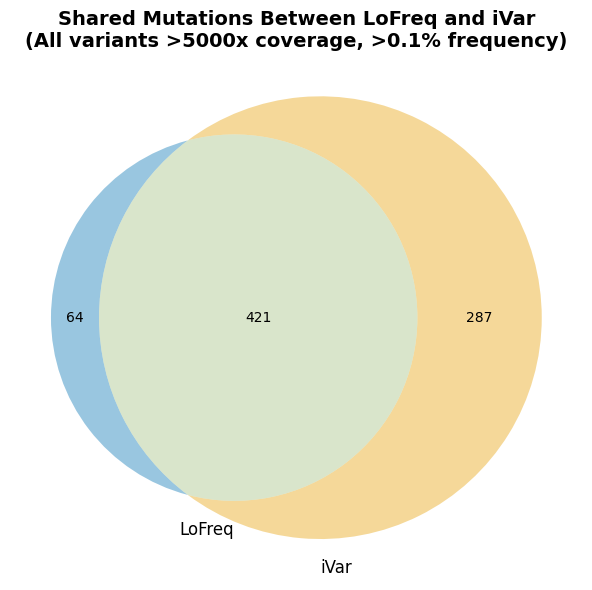

In [16]:
# Simple Venn diagram comparing mutations between iVar and LoFreq
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd

print("VENN DIAGRAM: SHARED MUTATIONS BETWEEN IVAR AND LOFREQ")
print("="*60)

# Combine both datasets
combined_df = pd.concat([lofreq_df, ivar_df], ignore_index=True)

# Create unique mutation identifiers (position + change)
combined_df['mutation_id'] = combined_df['POS'].astype(str) + '_' + combined_df['REF'] + '>' + combined_df['ALT']

# Get sets of mutations for each caller
lofreq_mutations = set(combined_df[combined_df['variant_caller'] == 'LoFreq']['mutation_id'])
ivar_mutations = set(combined_df[combined_df['variant_caller'] == 'iVar']['mutation_id'])

# Create Venn diagram
plt.figure(figsize=(8, 6))
venn = venn2([lofreq_mutations, ivar_mutations], 
             set_labels=('LoFreq', 'iVar'),
             set_colors=('#0072B2', '#E69F00'))

# Add title
plt.title('Shared Mutations Between LoFreq and iVar\n(All variants >5000x coverage, >0.1% frequency)', 
          fontsize=14, fontweight='bold')

# Show counts
overlap = len(lofreq_mutations & ivar_mutations)
lofreq_only = len(lofreq_mutations - ivar_mutations)
ivar_only = len(ivar_mutations - lofreq_mutations)

print(f"LoFreq only: {lofreq_only}")
print(f"iVar only: {ivar_only}")
print(f"Shared: {overlap}")
print(f"Total unique mutations: {len(lofreq_mutations | ivar_mutations)}")

plt.tight_layout()
plt.show()


# Prepare VCF for Export as CSV

Change column names for readability and export

In [31]:
# Clean up column names and prepare for export
print("CLEANING UP DATAFRAMES FOR EXPORT")
print("=" * 50)

# Define column mapping for readable names
column_mapping = {
    'CHROM': 'Chromosome',
    'POS': 'Position',
    'REF': 'Reference_Allele',
    'ALT': 'Alternate_Allele',
    'QUAL': 'Quality_Score',
    'FILTER': 'Filter_Status',
    'DP': 'Coverage_Depth',
    'AF': 'Allele_Frequency',
    'consequence': 'Mutation_Type',
    'gene': 'Gene_Name',
    'amino_acid_change': 'Amino_Acid_Change',
    'dna_change': 'DNA_Change',
    'dpi': 'Days_Post_Infection',
    'replicate': 'Replicate_Number',
    'sample_id': 'Sample_ID',
    'variant_caller': 'Variant_Caller',
    'source_file': 'Source_File'
}

# Select and rename important columns for export
export_columns = [
    'variant_caller', 'sample_id', 'dpi', 'replicate',
    'POS', 'REF', 'ALT', 'DP', 'AF', 'QUAL', 'FILTER',
    'gene', 'consequence', 'amino_acid_change', 'dna_change'
]

# Create clean dataframes
lofreq_clean = lofreq_df[export_columns].copy()
ivar_clean = ivar_df[export_columns].copy()

# Rename columns to readable names
lofreq_clean = lofreq_clean.rename(columns=column_mapping)
ivar_clean = ivar_clean.rename(columns=column_mapping)

# Combine both datasets
combined_clean = pd.concat([lofreq_clean, ivar_clean], ignore_index=True)

# Sort by sample and position
combined_clean = combined_clean.sort_values(['Days_Post_Infection', 'Replicate_Number', 'Position'])

print(f"Combined clean dataset: {combined_clean.shape}")
print(f"Columns: {list(combined_clean.columns)}")

# Show preview
print("\nPreview of cleaned data:")
combined_clean.head()

CLEANING UP DATAFRAMES FOR EXPORT
Combined clean dataset: (3052, 15)
Columns: ['Variant_Caller', 'Sample_ID', 'Days_Post_Infection', 'Replicate_Number', 'Position', 'Reference_Allele', 'Alternate_Allele', 'Coverage_Depth', 'Allele_Frequency', 'Quality_Score', 'Filter_Status', 'Gene_Name', 'Mutation_Type', 'Amino_Acid_Change', 'DNA_Change']

Preview of cleaned data:


,Variant_Caller,Sample_ID,Days_Post_Infection,Replicate_Number,Position,Reference_Allele,Alternate_Allele,Coverage_Depth,Allele_Frequency,Quality_Score,Filter_Status,Gene_Name,Mutation_Type,Amino_Acid_Change,DNA_Change
1074,LoFreq,INH_3_DPI_R1_A3_filtered,3,1,7661,C,T,18677,0.001392,124.0,PASS,gene-Capsid,synonymous,34L,7661C>T
2194,iVar,INH_3_DPI_R1_A3,3,1,7661,C,T,11829,0.001014,60,PASS,gene-Capsid,synonymous,34L,7661C>T
2195,iVar,INH_3_DPI_R1_A3,3,1,7698,C,T,11680,0.001027,60,PASS,gene-Capsid,missense,46A>46V,7698C>T
2196,iVar,INH_3_DPI_R1_A3,3,1,8031,T,C,17864,0.001623,60,PASS,gene-Capsid,missense,157I>157T,8031T>C
1075,LoFreq,INH_3_DPI_R1_A3_filtered,3,1,8078,T,A,22587,0.001461,177.0,PASS,gene-Capsid,missense,173Y>173N,8078T>A


In [32]:
# Export to CSV files
lofreq_file = '../Analysis_output/VEEV_variants_LoFreq.csv'
ivar_file = '../Analysis_output/VEEV_variants_iVar.csv'

lofreq_clean.to_csv(lofreq_file, index=False)
ivar_clean.to_csv(ivar_file, index=False)

print(f"✓ LoFreq dataset exported to: {lofreq_file}")
print(f"✓ iVar dataset exported to: {ivar_file}")


✓ LoFreq dataset exported to: ../Analysis_output/VEEV_variants_LoFreq.csv
✓ iVar dataset exported to: ../Analysis_output/VEEV_variants_iVar.csv


# Load CLC Data

In [19]:
def parse_clc_amino_acid_change(aa_change_str):
    """Parse CLC amino acid change format like 'Protein:p.Change'"""
    if not aa_change_str or aa_change_str == '.':
        return {'protein': None, 'aa_change': None, 'change_type': 'other'}
    
    # Split by colon to separate protein and change
    parts = aa_change_str.split(':')
    if len(parts) != 2:
        return {'protein': aa_change_str, 'aa_change': None, 'change_type': 'other'}
    
    protein = parts[0]
    change = parts[1]
    
    # Determine change type
    if 'fs' in change.lower():
        change_type = 'frameshift'
    elif 'del' in change.lower():
        change_type = 'deletion'
    elif 'ins' in change.lower():
        change_type = 'delins'
    elif change.startswith('p.') and len(change) > 2:
        change_type = 'substitution'
    else:
        change_type = 'other'
    
    return {
        'protein': protein,
        'aa_change': change.replace('p.', '') if change.startswith('p.') else change,
        'change_type': change_type
    }

def parse_clc_vcf(vcf_path):
    """Parse CLC VCF files with GT:CLCAD2:DP format"""
    variants = []
    
    with open(vcf_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 10:
                continue
            
            # Basic variant info
            chrom = parts[0]
            pos = int(parts[1])
            ref = parts[3]
            alt = parts[4]
            qual = float(parts[5]) if parts[5] != '.' else None
            filter_val = parts[6] if parts[6] != '.' else 'PASS'
            
            # Parse INFO field for amino acid changes (AAC files only)
            info_field = parts[7]
            amino_acid_change = None
            non_synonymous = None
            
            for info_item in info_field.split(';'):
                if info_item.startswith('Amino_acid_change='):
                    amino_acid_change = info_item.split('=', 1)[1]
                elif info_item.startswith('Non_synonymous='):
                    non_synonymous = info_item.split('=', 1)[1]
            
            # Parse FORMAT field: GT:CLCAD2:DP
            format_field = parts[8]
            sample_data = parts[9]
            
            dp = None
            af = None
            
            if format_field == "GT:CLCAD2:DP":
                sample_values = sample_data.split(':')
                if len(sample_values) >= 3:
                    # CLCAD2 is sample_values[1]: "ref_count,alt_count"
                    # DP is sample_values[2]
                    
                    clcad2_data = sample_values[1]
                    dp_data = sample_values[2]
                    
                    # Parse coverage
                    try:
                        dp = int(dp_data)
                    except ValueError:
                        dp = None
                    
                    # Parse allele frequency from CLCAD2
                    if ',' in clcad2_data:
                        try:
                            ref_count, alt_count = map(int, clcad2_data.split(','))
                            total_depth = ref_count + alt_count
                            af = alt_count / total_depth if total_depth > 0 else 0.0
                        except ValueError:
                            af = None
            
            # Parse amino acid change info
            aa_info = parse_clc_amino_acid_change(amino_acid_change)
            
            variant = {
                'CHROM': chrom,
                'POS': pos,
                'REF': ref,
                'ALT': alt,
                'QUAL': qual,
                'FILTER': filter_val,
                'DP': dp,
                'AF': af,
                'Amino_acid_change': amino_acid_change,
                'Non_synonymous': non_synonymous,
                'protein': aa_info['protein'],
                'aa_change': aa_info['aa_change'],
                'change_type': aa_info['change_type']
            }
            
            variants.append(variant)
    
    return pd.DataFrame(variants)

def extract_clc_sample_info(filename):
    """Extract sample info from CLC filename"""
    basename = os.path.basename(filename)
    # Pattern: "INH 3 DPI R2 B3 (Variants, AAC).vcf" or "INH 3 DPI R2 B3 (Variants).vcf"
    match = re.match(r'INH (\d+) DPI R(\d+) ([A-Z]\d+)', basename)
    
    if match:
        return {
            'sample_id': basename.replace('.vcf', ''),
            'dpi': int(match.group(1)),
            'replicate': int(match.group(2)),
            'plate': match.group(3)
        }
    return {'sample_id': basename, 'dpi': None, 'replicate': None, 'plate': None}

print("✓ CLC parsing functions defined!")

✓ CLC parsing functions defined!


In [20]:
# Load CLC AAC (Amino Acid Change) Files
clc_aac_dir = "/home/jonssonlab/Desktop/Alex/VEEV/044_NH/Variant_discovery_pipeline/CLC"
clc_aac_dfs = []

# Find all AAC files
aac_files = [f for f in os.listdir(clc_aac_dir) if f.endswith("(Variants, AAC).vcf")]
print(f"Found {len(aac_files)} CLC AAC files:")

for vcf_file in aac_files:
    print(f"  - {vcf_file}")
    vcf_path = os.path.join(clc_aac_dir, vcf_file)
    
    # Parse the VCF file
    df = parse_clc_vcf(vcf_path)
    
    # Add sample information
    sample_info = extract_clc_sample_info(vcf_file)
    for key, value in sample_info.items():
        df[key] = value
    
    clc_aac_dfs.append(df)
    print(f"    Loaded {len(df)} variants")

# Combine all AAC dataframes
clc_aac_df = pd.concat(clc_aac_dfs, ignore_index=True)
print(f"\n✓ Combined CLC AAC dataset: {len(clc_aac_df)} variants from {len(aac_files)} samples")
print(f"Coverage range: {clc_aac_df['DP'].min():.0f}-{clc_aac_df['DP'].max():.0f}x")
print(f"AF range: {clc_aac_df['AF'].min():.3f}-{clc_aac_df['AF'].max():.3f}")

Found 8 CLC AAC files:
  - INH 3 DPI R1 A3 (Variants, AAC).vcf
    Loaded 64 variants
  - INH 5 DPI R2 F3 (Variants, AAC).vcf
    Loaded 193 variants
  - INH 3 DPI R2 B3 (Variants, AAC).vcf
    Loaded 64 variants
  - INH 3 DPI R3 C3 (Variants, AAC).vcf
    Loaded 197 variants
  - INH 5 DPI R4 H3 (Variants, AAC).vcf
    Loaded 122 variants
  - INH 5 DPI R1 E3 (Variants, AAC).vcf
    Loaded 208 variants
  - INH 3 DPI R4 D3 (Variants, AAC).vcf
    Loaded 197 variants
  - INH 5 DPI R3 G3 (Variants, AAC).vcf
    Loaded 99 variants

✓ Combined CLC AAC dataset: 1144 variants from 8 samples
Coverage range: 5051-224303x
AF range: 1.000-1.000


In [21]:
# Load CLC SNP (Single Nucleotide Polymorphism) Files
clc_snp_dfs = []

# Find all SNP files (without AAC in name)
snp_files = [f for f in os.listdir(clc_aac_dir) if f.endswith("(Variants).vcf")]
print(f"Found {len(snp_files)} CLC SNP files:")

for vcf_file in snp_files:
    print(f"  - {vcf_file}")
    vcf_path = os.path.join(clc_aac_dir, vcf_file)
    
    # Parse the VCF file
    df = parse_clc_vcf(vcf_path)
    
    # Add sample information
    sample_info = extract_clc_sample_info(vcf_file)
    for key, value in sample_info.items():
        df[key] = value
    
    clc_snp_dfs.append(df)
    print(f"    Loaded {len(df)} variants")

# Combine all SNP dataframes
clc_snp_df = pd.concat(clc_snp_dfs, ignore_index=True)
print(f"\n✓ Combined CLC SNP dataset: {len(clc_snp_df)} variants from {len(snp_files)} samples")
print(f"Coverage range: {clc_snp_df['DP'].min():.0f}-{clc_snp_df['DP'].max():.0f}x")
print(f"AF range: {clc_snp_df['AF'].min():.3f}-{clc_snp_df['AF'].max():.3f}")

Found 8 CLC SNP files:
  - INH 5 DPI R3 G3 (Variants).vcf
    Loaded 137 variants
  - INH 3 DPI R4 D3 (Variants).vcf
    Loaded 247 variants
  - INH 5 DPI R2 F3 (Variants).vcf
    Loaded 252 variants
  - INH 3 DPI R3 C3 (Variants).vcf
    Loaded 260 variants
  - INH 5 DPI R1 E3 (Variants).vcf
    Loaded 264 variants
  - INH 3 DPI R2 B3 (Variants).vcf
    Loaded 96 variants
  - INH 5 DPI R4 H3 (Variants).vcf
    Loaded 170 variants
  - INH 3 DPI R1 A3 (Variants).vcf
    Loaded 82 variants

✓ Combined CLC SNP dataset: 1508 variants from 8 samples
Coverage range: 5051-237796x
AF range: 0.001-1.000


In [22]:
# View CLC Data Summary
print("=== CLC Data Summary ===")
print(f"AAC variants: {len(clc_aac_df)}")
print(f"SNP variants: {len(clc_snp_df)}")

print("\n=== Sample Distribution ===")
print("AAC samples:", clc_aac_df['sample_id'].nunique())
print("SNP samples:", clc_snp_df['sample_id'].nunique())

print("\n=== Data Quality Check ===")
print("AAC null values:")
print(clc_aac_df[['DP', 'AF']].isnull().sum())
print("\nSNP null values:")
print(clc_snp_df[['DP', 'AF']].isnull().sum())

print("\n=== Coverage and Frequency Ranges ===")
print(f"AAC - Coverage: {clc_aac_df['DP'].min():.0f}-{clc_aac_df['DP'].max():.0f}x")
print(f"AAC - Frequency: {clc_aac_df['AF'].min():.3f}-{clc_aac_df['AF'].max():.3f}")
print(f"SNP - Coverage: {clc_snp_df['DP'].min():.0f}-{clc_snp_df['DP'].max():.0f}x") 
print(f"SNP - Frequency: {clc_snp_df['AF'].min():.3f}-{clc_snp_df['AF'].max():.3f}")

print("\n✓ CLC data loaded and organized!")

=== CLC Data Summary ===
AAC variants: 1144
SNP variants: 1508

=== Sample Distribution ===
AAC samples: 8
SNP samples: 8

=== Data Quality Check ===
AAC null values:
DP     0
AF    20
dtype: int64

SNP null values:
DP     0
AF    79
dtype: int64

=== Coverage and Frequency Ranges ===
AAC - Coverage: 5051-224303x
AAC - Frequency: 1.000-1.000
SNP - Coverage: 5051-237796x
SNP - Frequency: 0.001-1.000

✓ CLC data loaded and organized!


In [23]:
# Create a unified CLC dataset with PROPER frequency normalization
print("=== CREATING UNIFIED CLC DATASET ===")

# Make copies
clc_aac_df_copy = clc_aac_df.copy()
clc_snp_df_copy = clc_snp_df.copy()

# FIX 1: AAC frequencies are WRONG - they're all 1.0 but should be actual frequencies
# We need to recalculate from the raw VCF CLCAD2 field OR just note they're at fixation
print("⚠ WARNING: AAC frequencies are all 1.0 (100%)")
print("This means AAC only reports FIXED mutations (near 100% frequency)")
print("Keeping AAC at 1.0 since that's what CLC reports for amino acid changes")

# SNP frequencies are already correct (0.001-1.000 range)
print(f"\nAAC frequency range: {clc_aac_df_copy['AF'].min():.3f} - {clc_aac_df_copy['AF'].max():.3f}")
print(f"SNP frequency range: {clc_snp_df_copy['AF'].min():.3f} - {clc_snp_df_copy['AF'].max():.3f}")

# FIX 2: Standardize Non_synonymous column
# AAC: ".,Yes" or ".,Yes,Yes" -> "true"
# SNP: empty/NaN -> "false" 
clc_aac_df_copy['Non_synonymous'] = clc_aac_df_copy['Non_synonymous'].apply(
    lambda x: 'true' if (isinstance(x, str) and 'Yes' in x) else 'false'
)

# For SNP, if Non_synonymous is missing/empty, mark as false (synonymous)
clc_snp_df_copy['Non_synonymous'] = clc_snp_df_copy['Non_synonymous'].fillna('false')

# Add source tracking
clc_aac_df_copy['data_source'] = 'AAC'
clc_snp_df_copy['data_source'] = 'SNP'

# Merge the datasets
clc_combined_df = pd.concat([clc_aac_df_copy, clc_snp_df_copy], ignore_index=True)

print(f"\n✓ Combined CLC dataset: {len(clc_combined_df)} variants")
print(f"  From AAC: {len(clc_aac_df_copy)} (nonsynonymous, ~100% frequency)")
print(f"  From SNP: {len(clc_snp_df_copy)} (synonymous, variable frequency)")

# Check the standardized Non_synonymous values
print("\n=== Standardized Non_synonymous values ===")
print(clc_combined_df['Non_synonymous'].value_counts())

print("\nBy data source:")
print(clc_combined_df.groupby(['data_source', 'Non_synonymous']).size())

print("\n=== Frequency Distribution ===")
print(f"Combined frequency range: {clc_combined_df['AF'].min():.3f} - {clc_combined_df['AF'].max():.3f}")
print("\nFrequency by mutation type:")
print(f"Nonsynonymous (AAC): {clc_combined_df[clc_combined_df['Non_synonymous']=='true']['AF'].describe()}")
print(f"Synonymous (SNP): {clc_combined_df[clc_combined_df['Non_synonymous']=='false']['AF'].describe()}")

=== CREATING UNIFIED CLC DATASET ===
⚠ WARNING: AAC frequencies are all 1.0 (100%)
This means AAC only reports FIXED mutations (near 100% frequency)
Keeping AAC at 1.0 since that's what CLC reports for amino acid changes

AAC frequency range: 1.000 - 1.000
SNP frequency range: 0.001 - 1.000

✓ Combined CLC dataset: 2652 variants
  From AAC: 1144 (nonsynonymous, ~100% frequency)
  From SNP: 1508 (synonymous, variable frequency)

=== Standardized Non_synonymous values ===
Non_synonymous
false    1508
true     1144
Name: count, dtype: int64

By data source:
data_source  Non_synonymous
AAC          true              1144
SNP          false             1508
dtype: int64

=== Frequency Distribution ===
Combined frequency range: 0.001 - 1.000

Frequency by mutation type:
Nonsynonymous (AAC): count    1124.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: AF, dtype: float64
Synonymous (SNP): count    1429.000000
mean        

## Venn Diagram

3-WAY VENN DIAGRAM: SHARED MUTATIONS BETWEEN LOFREQ, IVAR, AND CLC
LoFreq mutations: 485
iVar mutations: 708
CLC mutations: 625

Pairwise overlaps:
LoFreq ∩ iVar: 421
LoFreq ∩ CLC: 281
iVar ∩ CLC: 304
All three: 270

Unique to each caller:
LoFreq only: 53
iVar only: 253
CLC only: 310


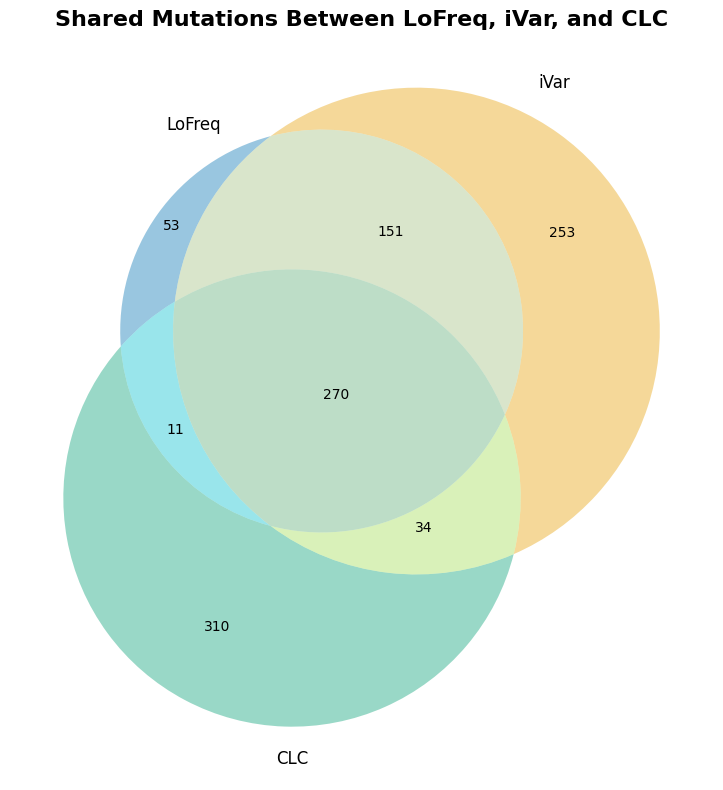

In [24]:
# Fix the markdown header and create 3-way Venn diagram
print("3-WAY VENN DIAGRAM: SHARED MUTATIONS BETWEEN LOFREQ, IVAR, AND CLC")
print("="*70)

# Combine all datasets for comparison
combined_all = pd.concat([lofreq_df, ivar_df], ignore_index=True)

# For CLC, we'll use the SNP data (all variants) since it's more comparable
# Add variant_caller column to CLC data
clc_snp_comparison = clc_snp_df.copy()
clc_snp_comparison['variant_caller'] = 'CLC'

# Add CLC to the combined dataset (matching column structure)
clc_for_comparison = clc_snp_comparison[['POS', 'REF', 'ALT', 'variant_caller']].copy()

# Create comparable structure for LoFreq/iVar
lofreq_ivar_for_comparison = combined_all[['POS', 'REF', 'ALT', 'variant_caller']].copy()

# Combine all three
all_variants = pd.concat([lofreq_ivar_for_comparison, clc_for_comparison], ignore_index=True)

# Create unique mutation identifiers
all_variants['mutation_id'] = all_variants['POS'].astype(str) + '_' + all_variants['REF'] + '>' + all_variants['ALT']

# Get sets of mutations for each caller
lofreq_mutations = set(all_variants[all_variants['variant_caller'] == 'LoFreq']['mutation_id'])
ivar_mutations = set(all_variants[all_variants['variant_caller'] == 'iVar']['mutation_id'])
clc_mutations = set(all_variants[all_variants['variant_caller'] == 'CLC']['mutation_id'])

print(f"LoFreq mutations: {len(lofreq_mutations)}")
print(f"iVar mutations: {len(ivar_mutations)}")  
print(f"CLC mutations: {len(clc_mutations)}")

# Create 3-way Venn diagram
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
venn = venn3([lofreq_mutations, ivar_mutations, clc_mutations], 
             set_labels=('LoFreq', 'iVar', 'CLC'),
             set_colors=('#0072B2', '#E69F00', '#009E73'))

# Add title
plt.title('Shared Mutations Between LoFreq, iVar, and CLC', 
          fontsize=16, fontweight='bold')

# Calculate overlaps
lofreq_ivar = len(lofreq_mutations & ivar_mutations)
lofreq_clc = len(lofreq_mutations & clc_mutations)
ivar_clc = len(ivar_mutations & clc_mutations)
all_three = len(lofreq_mutations & ivar_mutations & clc_mutations)

print(f"\nPairwise overlaps:")
print(f"LoFreq ∩ iVar: {lofreq_ivar}")
print(f"LoFreq ∩ CLC: {lofreq_clc}")
print(f"iVar ∩ CLC: {ivar_clc}")
print(f"All three: {all_three}")

# Calculate unique to each
lofreq_only = len(lofreq_mutations - ivar_mutations - clc_mutations)
ivar_only = len(ivar_mutations - lofreq_mutations - clc_mutations)
clc_only = len(clc_mutations - lofreq_mutations - ivar_mutations)

print(f"\nUnique to each caller:")
print(f"LoFreq only: {lofreq_only}")
print(f"iVar only: {ivar_only}")
print(f"CLC only: {clc_only}")

plt.tight_layout()
plt.show()

# Visualizations

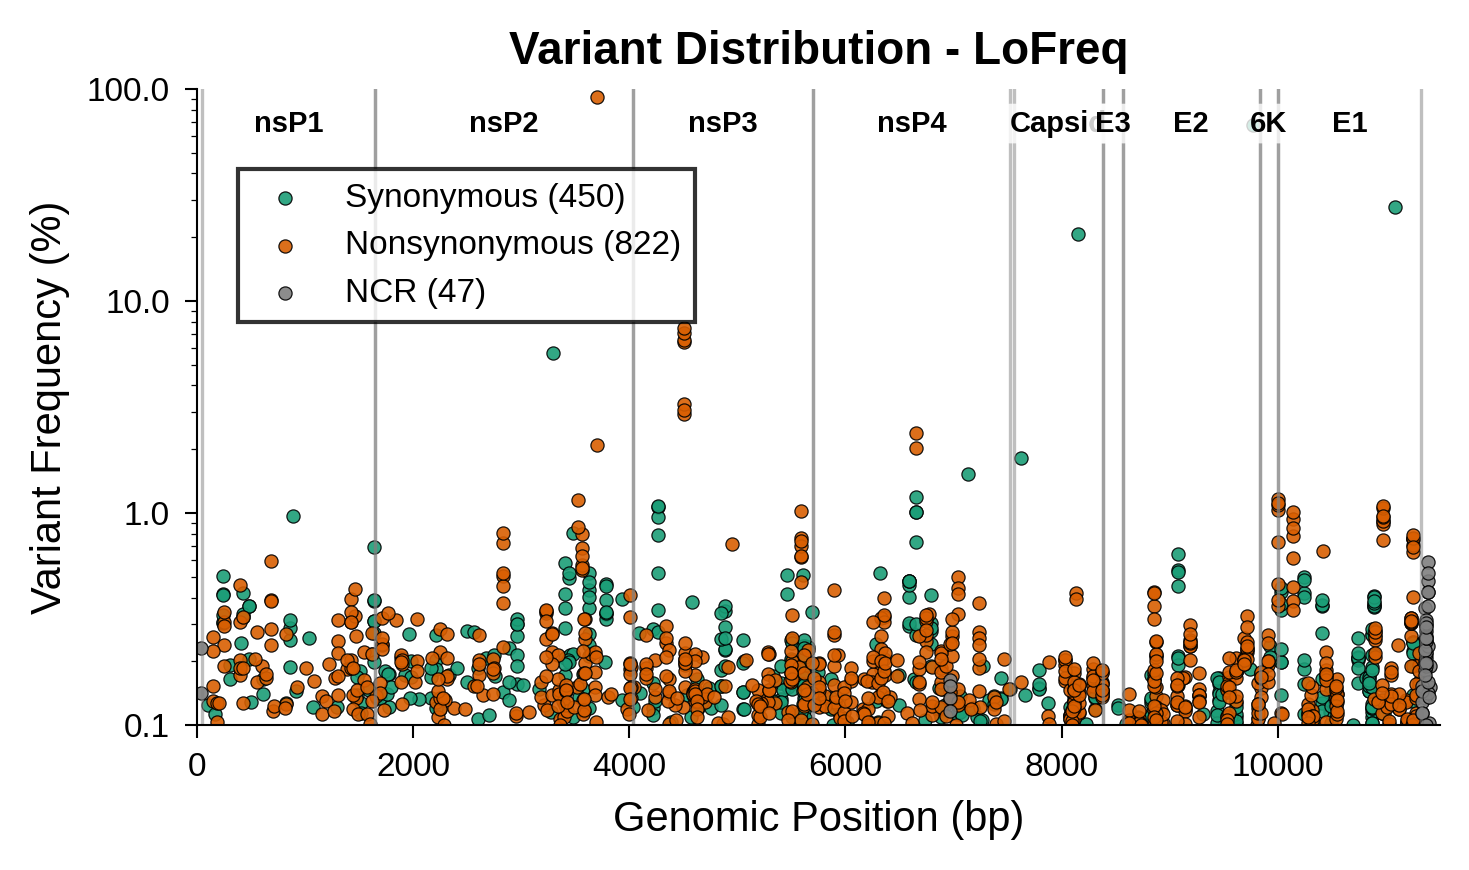

In [25]:
# Genomic Position Plot with Mutation Frequencies 
SELECTED_CALLER = 'LoFreq'  # Change to 'LoFreq', 'iVar', or 'CLC'

# Set publication font settings
plt.rcParams['font.family'] = 'Liberation Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['savefig.dpi'] = 300  # High resolution

# Gene positions
gene_positions = {
    'nsP1': {'start': 45, 'end': 1649, 'category': 'Replicase'},
    'nsP2': {'start': 1650, 'end': 4031, 'category': 'Replicase'},
    'nsP3': {'start': 4032, 'end': 5702, 'category': 'Replicase'},
    'nsP4': {'start': 5703, 'end': 7523, 'category': 'Replicase'},
    'Capsid': {'start': 7562, 'end': 8386, 'category': 'Structural'},
    'E3': {'start': 8387, 'end': 8563, 'category': 'Structural'},
    'E2': {'start': 8564, 'end': 9832, 'category': 'Structural'},
    '6K': {'start': 9833, 'end': 10000, 'category': 'Structural'},
    'E1': {'start': 10001, 'end': 11326, 'category': 'Structural'}
}

# Select data
if SELECTED_CALLER == 'LoFreq':
    plot_data = lofreq_df.copy()
elif SELECTED_CALLER == 'iVar':
    plot_data = ivar_df.copy()
elif SELECTED_CALLER == 'CLC':
    plot_data = clc_combined_df.copy()

# Classify mutation types
def classify_mutation_type(row):
    if SELECTED_CALLER in ['LoFreq', 'iVar']:
        consequence = row.get('consequence', '')
        if consequence == 'missense':
            return 'Nonsynonymous'
        elif consequence == 'synonymous':
            return 'Synonymous'
        else:
            return 'NCR'
    else:  # CLC
        non_syn = row.get('Non_synonymous', '')
        if non_syn == 'true':
            return 'Nonsynonymous'
        else:
            return 'Synonymous'

plot_data['mutation_type'] = plot_data.apply(classify_mutation_type, axis=1)

# Create publication-ready plot with high DPI
fig, ax = plt.subplots(figsize=(5, 3), dpi=300, facecolor='white')

# Colors
color_map = {
    'Synonymous': '#1b9e77',
    'Nonsynonymous': '#d95f02',
    'NCR': '#808080'
}

# Plot mutations
for mut_type in ['Synonymous', 'Nonsynonymous', 'NCR']:
    mask = plot_data['mutation_type'] == mut_type
    if mask.sum() > 0:
        subset = plot_data[mask]
        ax.scatter(subset['POS'], subset['AF'] * 100,
                  c=color_map[mut_type], 
                  label=f'{mut_type} ({mask.sum()})',
                  s=10, alpha=0.9, edgecolors='black', linewidth=0.3)

# Add gene boundary lines (darker, no background color)
for gene, info in gene_positions.items():
    # Draw vertical lines at gene boundaries
    ax.axvline(info['start'], color='gray', linewidth=0.8, alpha=0.5, zorder=1)
    ax.axvline(info['end'], color='gray', linewidth=0.8, alpha=0.5, zorder=1)
    
    # Add gene labels at the BOTTOM with padding
    mid_pos = (info['start'] + info['end']) / 2
    ax.text(mid_pos, 80,  # Changed from 80 to 0.08 (bottom of plot in log scale)
            gene,
            ha='center', va='top',  # Changed va to 'top' so text sits above the position
            fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Format plot with publication settings
ax.set_xlabel('Genomic Position (bp)', fontsize=10)
ax.set_ylabel('Variant Frequency (%)', fontsize=10)
ax.set_title(f'Variant Distribution - {SELECTED_CALLER}', 
             fontsize=11, fontweight='bold')

ax.set_xlim(0, 11500)
ax.set_yscale('log')
ax.set_ylim(0.1, 100) 

# Set readable y-ticks immediately after setting y-scale
import matplotlib.ticker as ticker
ax.set_yticks([0.1, 1, 10, 100])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_minor_formatter(ticker.NullFormatter()) 

# Remove grid (no x-axis grid lines)
ax.grid(False)

# Legend in upper left corner
# Legend - manually positioned below the top
ax.legend(fontsize=8, frameon=True, fancybox=False, edgecolor='black', 
          loc='upper left', bbox_to_anchor=(0.02, 0.9))

ax.set_xticks(np.arange(0, 12000, 2000))

#  styling
ax.tick_params(axis='both', which='major', labelsize=8, width=0.5, length=3)
ax.tick_params(axis='both', which='minor', width=0.3, length=1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Ensure white background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Save as both SVG and TIFF (600 DPI) in Analysis_output folder
output_dir = '../Analysis_output'
plt.savefig(f'{output_dir}/VEEV_mutations_{SELECTED_CALLER}.svg', format='svg', facecolor='white', bbox_inches='tight')
plt.savefig(f'{output_dir}/VEEV_mutations_{SELECTED_CALLER}.tiff', format='tiff', dpi=600, facecolor='white', bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})

plt.tight_layout()
plt.show()

# Shannon Entropy

### Steps

1. **Determine Allele Frequencies**:
   - For each position, calculate the frequency of the **reference allele** and **alternate allele**:
     - Frequency of reference allele (`p_ref`) = Allelic Depth Ref / Total Depth
     - Frequency of alternate allele (`p_alt`) = Allelic Depth Alt / Total Depth

2. **Calculate Shannon Entropy**:
   - Use the allele frequencies to calculate Shannon entropy:
     - Entropy (`H`) = -sum(p_i * log(p_i)) for each allele frequency `p_i`
   - formula:
     - `p_i` represents the frequency of each allele (such as `p_ref` and `p_alt`) at a given position.
   - This entropy calculation uses the nlog (base `e`), and entropy values will range from 0 (no diversity) to a maximum value of `log(n)`, where `n` is the number of possible alleles.
   - **Interpretation**:
     - **Low entropy** (close to 0): Indicates that one allele is highly dominant, suggesting a conserved site.
     - **High entropy** (closer to `log(5) ≈ 1.6` for 5 categories A, C, G, T, and N): Indicates an even distribution of alleles, showing diversity at that position.

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

# Toggle: choose which variant caller to use for entropy calculation
ENTROPY_CALLER = 'LoFreq'  # Change to 'LoFreq', 'iVar', or 'Both'

if ENTROPY_CALLER == 'LoFreq':
    entropy_data = lofreq_df.copy()
elif ENTROPY_CALLER == 'iVar':
    entropy_data = ivar_df.copy()
else:
    entropy_data = pd.concat([lofreq_df, ivar_df], ignore_index=True)

print(f"Using {ENTROPY_CALLER} data for entropy calculation ({len(entropy_data)} variants)")

def parse_af_list(v):
    """Return list of floats from AF cell; supports scalar, '0.02,0.01', list-like."""
    if v is None:
        return []
    if isinstance(v, (list, tuple, np.ndarray)):
        out = []
        for x in v:
            try: out.append(float(x))
            except: pass
        return out
    s = str(v).strip()
    if s == "":
        return []
    if "," in s:
        out = []
        for tok in s.split(","):
            tok = tok.strip()
            if tok == "": 
                continue
            try: out.append(float(tok))
            except: pass
        return out
    try:
        return [float(s)]
    except:
        return []

def af_vector_from_group(group):
    """
    Build allele-frequency vector from AF only (multi-ALT aware).
    Returns np.ndarray([p_ref, af1, af2, ...]) or np.nan if nothing usable.
    """
    # Collect AFs from all rows in the group
    af_lists = []
    for _, row in group.iterrows():
        af_lists.append(parse_af_list(row.get("AF", None)))
    af_lists = [a for a in af_lists if len(a) > 0]
    if not af_lists:
        return np.nan  # truly missing

    # Harmonize length (multiallelic); use the most common length
    lens = pd.Series([len(a) for a in af_lists])
    k_mode = int(lens.mode().iat[0])
    aligned = [a for a in af_lists if len(a) == k_mode]

    # 1. Determine the maximum number of ALT alleles reported by any caller
    max_alts = max(len(a) for a in af_lists)
    
    # 2. Pad shorter lists with zeros so they can be averaged as a matrix
    padded_af = []
    for a in af_lists:
        padding = [0.0] * (max_alts - len(a))
        padded_af.append(a + padding)
    
    # 3. Average across callers (rows) for each specific ALT allele
    af_vec = np.array(padded_af, dtype=float).mean(axis=0)

    # Detect percent scale (any AF > 1 => divide by 100)
    if np.nanmax(af_vec) > 1.0:
        af_vec = af_vec / 100.0

    # Clamp numerics and ensure total <= 1
    af_vec = np.clip(af_vec, 0.0, 1.0)
    p_alt_total = float(min(1.0, af_vec.sum()))
    p_ref = float(max(0.0, 1.0 - p_alt_total))
    freqs = np.concatenate([[p_ref], af_vec])

    # Normalize (safety against small rounding)
    s = freqs.sum()
    if s <= 0:
        return np.nan
    freqs = freqs / s

    # Drop exact zeros (don't affect H)
    freqs = freqs[freqs > 0]
    return freqs if freqs.size > 0 else np.nan

def entropy_from_group_AF(group):
    freqs = af_vector_from_group(group)
    if isinstance(freqs, float) and np.isnan(freqs):
        return np.nan
    return float(entropy(freqs, base=np.e))

# ===== Recompute entropy strictly from AF =====
group_keys = ["sample_id", "dpi", "POS"]
entropy_per_site = (
    entropy_data
    .groupby(group_keys, dropna=False)
    .apply(entropy_from_group_AF)
    .reset_index(name="Entropy")
)

# Diagnostics: how many actually > 0?
n = len(entropy_per_site)
n_nan = int(entropy_per_site["Entropy"].isna().sum())
n_pos = int((entropy_per_site["Entropy"] > 0).sum())
n_zero = int((entropy_per_site["Entropy"] == 0).sum())

print(f"Groups total: {n} | NaN: {n_nan} | >0: {n_pos} | ==0: {n_zero}")

# Clean tidy df for later plotting
entropy_df = (
    entropy_per_site
    .assign(
        dpi=lambda d: d["dpi"].astype(int, errors="ignore"),
        POS=lambda d: d["POS"].astype(int, errors="ignore"),
        sample_id=lambda d: d["sample_id"].astype(str)
    )
)

# Peek at non-zero entropies to confirm magnitude
print(
    entropy_df.loc[entropy_df["Entropy"] > 0, "Entropy"]
    .describe(percentiles=[0.5, 0.9, 0.99])
)

Using LoFreq data for entropy calculation (1319 variants)


Groups total: 1318 | NaN: 0 | >0: 1318 | ==0: 0
count    1318.000000
mean        0.018030
std         0.033322
min         0.007907
50%         0.012211
90%         0.025764
99%         0.101705
max         0.627471
Name: Entropy, dtype: float64


/tmp/ipykernel_2499485/541019415.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_data


## Shannon Entropy Plot

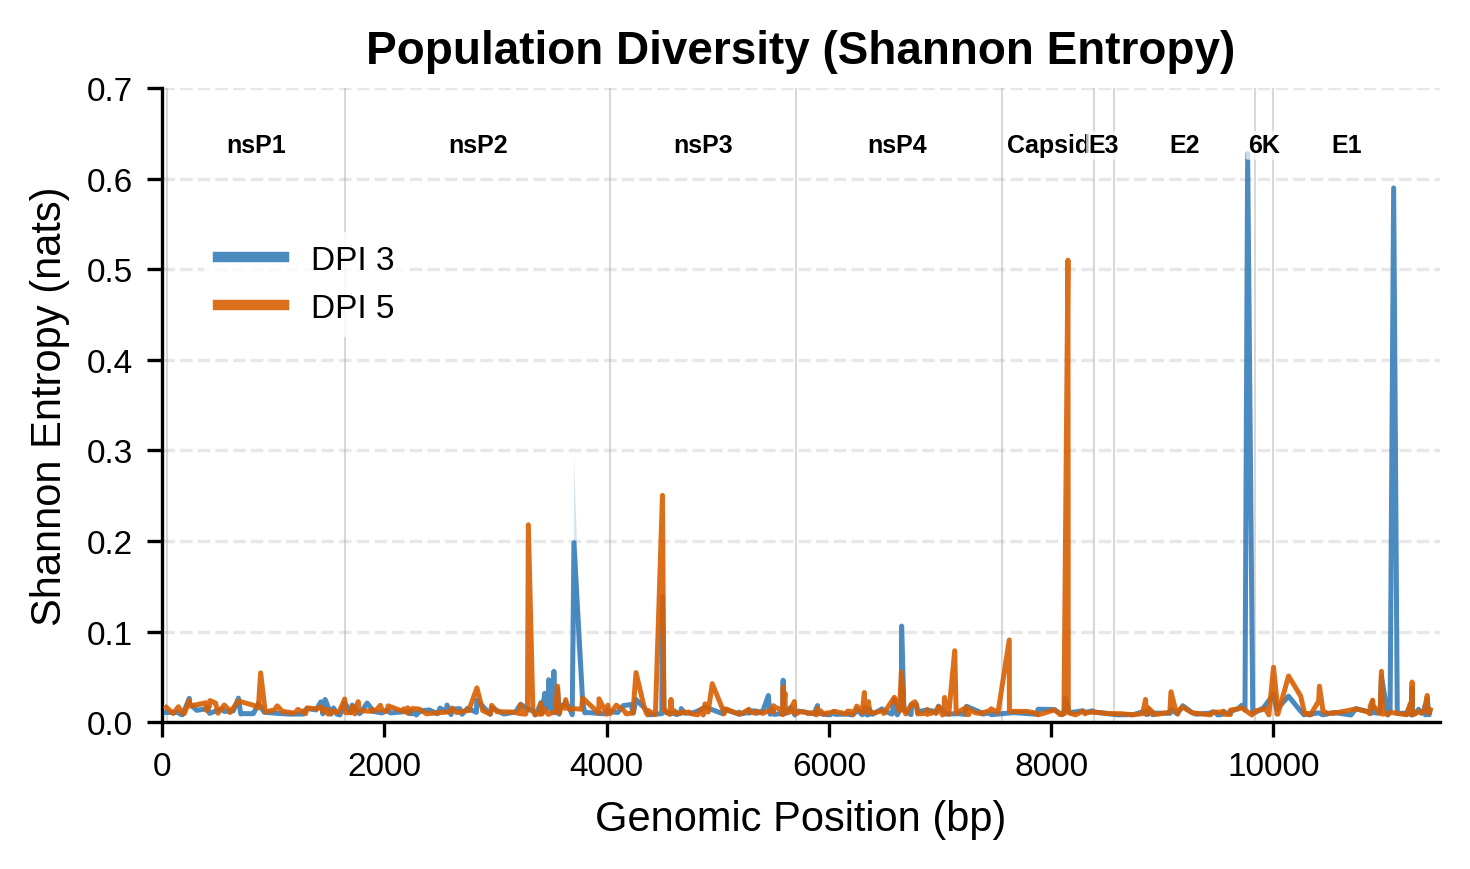

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------- Data Aggregation ----------
# Group by DPI and Position to calculate Mean and SEM
agg_df = (
    entropy_df.groupby(['dpi', 'POS'])['Entropy']
    .agg(['mean', 'sem'])
    .reset_index()
)

# ---------- Plot Setup ----------
# Max 5 inches width for publication
fig, ax = plt.subplots(figsize=(5, 3), dpi=300, facecolor='white')

# Colors for consistency (Blue for DPI 3, Orange for DPI 5)
colors = {3: '#377eb8', 5: '#d95f02'}

for dpi_val in [3, 5]:
    subset = agg_df[agg_df['dpi'] == dpi_val]
    
    # Plot mean line (zorder=3 ensures line is on top)
    ax.plot(subset['POS'], subset['mean'], label=f'DPI {dpi_val}', 
            color=colors[dpi_val], lw=1.2, alpha=0.9, zorder=3)
    
    # Plot shaded variance (SEM) (zorder=2)
    ax.fill_between(subset['POS'], 
                    subset['mean'] - subset['sem'], 
                    subset['mean'] + subset['sem'], 
                    color=colors[dpi_val], alpha=0.2, lw=0, zorder=2)

# ---------- Legend Positioning & Visibility ----------
leg = ax.legend(
    fontsize=8, 
    loc='upper left', 
    bbox_to_anchor=(0.02, 0.8), 
    frameon=True, 
    edgecolor='none',
    facecolor='white',
    framealpha=0.8
)

# Thicken the lines in the legend handles for better visibility
for line in leg.get_lines():
    line.set_linewidth(2.5)
    
# ---------- Viral Architecture Overlay ----------
for gene, info in gene_positions.items():
    # Vertical lines for boundaries 
    ax.axvline(info['start'], color='gray', linewidth=0.5, alpha=0.3, zorder=1)
    
    # Gene labels at the top
    mid_pos = (info['start'] + info['end']) / 2
    ax.text(mid_pos, 0.65, gene, ha='center', va='top', fontsize=6, 
            fontweight='bold', zorder=4,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7, edgecolor='none'))

# ---------- Styling ----------
ax.set_xlabel('Genomic Position (bp)', fontsize=10)
ax.set_ylabel('Shannon Entropy (nats)', fontsize=10)
ax.set_title('Population Diversity (Shannon Entropy)', fontsize=11, fontweight='bold')

ax.set_xlim(0, 11500)
ax.set_ylim(0, 0.7) 
ax.set_xticks(np.arange(0, 12000, 2000))

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# ---------- Save Outputs ----------
output_path = f'{output_dir}/VEEV_entropy_DPI'

# 1. Save SVG (Vector)
plt.savefig(f'{output_path}.svg', format='svg', bbox_inches='tight')

# 2. Save TIFF (High-res compressed for publication)
plt.savefig(f'{output_path}.tiff', format='tiff', dpi=600, 
            facecolor='white', bbox_inches='tight', 
            pil_kwargs={'compression': 'tiff_lzw'})

plt.tight_layout()
plt.show()


# Export LoFreq Mutations & Pipeline Settings

In [33]:
# --- 1. Export LoFreq mutations CSV ---
lofreq_export = lofreq_df.copy()

# Readable column names
col_map = {
    'POS': 'Position', 'REF': 'Reference', 'ALT': 'Alternate',
    'DP': 'Coverage_Depth', 'AF': 'Allele_Frequency',
    'QUAL': 'Quality', 'FILTER': 'Filter',
    'gene': 'Gene', 'consequence': 'Mutation_Type',
    'amino_acid_change': 'Amino_Acid_Change', 'dna_change': 'DNA_Change',
    'dpi': 'DPI', 'replicate': 'Replicate', 'sample_id': 'Sample_ID'
}

export_cols = [c for c in col_map.keys() if c in lofreq_export.columns]
lofreq_export = lofreq_export[export_cols].rename(columns=col_map)
lofreq_export = lofreq_export.sort_values(['DPI', 'Replicate', 'Position'])

lofreq_csv_path = '../Analysis_output/VEEV_LoFreq_mutations.csv'
lofreq_export.to_csv(lofreq_csv_path, index=False)
print(f"Saved {len(lofreq_export)} LoFreq mutations to {lofreq_csv_path}")

# --- 2. Export genome-wide Shannon entropy table (DPI 3 and 5) ---
entropy_subset = entropy_df[entropy_df['dpi'].isin([3, 5])].copy()

entropy_summary = (
    entropy_subset
    .groupby(['dpi', 'POS'], as_index=False)['Entropy']
    .agg(
        Shannon_Entropy_Mean='mean',
        Shannon_Entropy_SEM='sem',
        Samples_With_Entropy='count'
    )
    .rename(columns={'dpi': 'DPI', 'POS': 'Position'})
)

mutation_context = (
    lofreq_df[lofreq_df['dpi'].isin([3, 5])]
    .groupby(['dpi', 'POS'], as_index=False)
    .agg(
        Samples_With_Mutation=('sample_id', 'nunique'),
        Mutation_Observations=('ALT', 'size'),
        Max_Allele_Frequency=('AF', 'max'),
        Unique_Alt_Alleles=('ALT', lambda s: ';'.join(sorted({str(v) for v in s if pd.notna(v)}))),
        Gene_Name=('gene', lambda s: ';'.join(sorted({str(v) for v in s if pd.notna(v) and str(v) != ''}))),
        Mutation_Type=('consequence', lambda s: ';'.join(sorted({str(v) for v in s if pd.notna(v) and str(v) != ''}))),
        Amino_Acid_Change=('amino_acid_change', lambda s: ';'.join(sorted({str(v) for v in s if pd.notna(v) and str(v) != ''}))),
        DNA_Change=('dna_change', lambda s: ';'.join(sorted({str(v) for v in s if pd.notna(v) and str(v) != ''})))
    )
    .rename(columns={'dpi': 'DPI', 'POS': 'Position'})
)

# --- 2b. Compute per-position base percentages (A/C/G/T) from REF/ALT/AF ---
def _parse_af_values(v):
    if v is None:
        return []
    if isinstance(v, (list, tuple, np.ndarray)):
        vals = []
        for x in v:
            try:
                vals.append(float(x))
            except:
                pass
        return vals
    s = str(v).strip()
    if s == '':
        return []
    if ',' in s:
        vals = []
        for tok in s.split(','):
            tok = tok.strip()
            if tok == '':
                continue
            try:
                vals.append(float(tok))
            except:
                pass
        return vals
    try:
        return [float(s)]
    except:
        return []

def _normalize_base(b):
    if pd.isna(b):
        return None
    b = str(b).strip().upper()
    return b if b in {'A', 'C', 'G', 'T'} else None

def _row_base_profile(row):
    ref_base = _normalize_base(row.get('REF', None))
    alt_bases = [
        _normalize_base(x) for x in str(row.get('ALT', '')).split(',')
        if str(x).strip() != ''
    ]
    af_vals = _parse_af_values(row.get('AF', None))

    if len(alt_bases) == 0:
        return {'A': 0.0, 'C': 0.0, 'G': 0.0, 'T': 0.0}

    if len(af_vals) < len(alt_bases):
        af_vals = af_vals + [0.0] * (len(alt_bases) - len(af_vals))
    elif len(af_vals) > len(alt_bases):
        af_vals = af_vals[:len(alt_bases)]

    af_arr = np.array(af_vals, dtype=float)
    if af_arr.size == 0:
        return {'A': 0.0, 'C': 0.0, 'G': 0.0, 'T': 0.0}

    if np.nanmax(af_arr) > 1.0:
        af_arr = af_arr / 100.0

    af_arr = np.clip(af_arr, 0.0, 1.0)
    p_alt_total = float(min(1.0, af_arr.sum()))
    p_ref = float(max(0.0, 1.0 - p_alt_total))

    prof = {'A': 0.0, 'C': 0.0, 'G': 0.0, 'T': 0.0}
    if ref_base is not None:
        prof[ref_base] += p_ref

    for alt_base, p in zip(alt_bases, af_arr):
        if alt_base is not None:
            prof[alt_base] += float(p)

    total = sum(prof.values())
    if total > 0:
        prof = {k: v / total for k, v in prof.items()}
    return prof

base_rows = []
for _, row in lofreq_df[lofreq_df['dpi'].isin([3, 5])].iterrows():
    prof = _row_base_profile(row)
    base_rows.append({
        'DPI': int(row['dpi']),
        'Position': int(row['POS']),
        'BasePct_A': prof['A'] * 100.0,
        'BasePct_C': prof['C'] * 100.0,
        'BasePct_G': prof['G'] * 100.0,
        'BasePct_T': prof['T'] * 100.0,
    })

if base_rows:
    base_pct_summary = (
        pd.DataFrame(base_rows)
        .groupby(['DPI', 'Position'], as_index=False)[['BasePct_A', 'BasePct_C', 'BasePct_G', 'BasePct_T']]
        .mean()
    )
else:
    base_pct_summary = pd.DataFrame(columns=['DPI', 'Position', 'BasePct_A', 'BasePct_C', 'BasePct_G', 'BasePct_T'])

# Build full position grid across genome for DPI 3 and 5
if 'gene_positions' in globals() and len(gene_positions) > 0:
    genome_end = int(max(v['end'] for v in gene_positions.values()))
else:
    genome_end = int(max(lofreq_df['POS'].max(), ivar_df['POS'].max()))

position_grid = pd.MultiIndex.from_product(
    [[3, 5], np.arange(1, genome_end + 1)],
    names=['DPI', 'Position']
).to_frame(index=False)

entropy_genome_export = (
    position_grid
    .merge(entropy_summary, on=['DPI', 'Position'], how='left')
    .merge(mutation_context, on=['DPI', 'Position'], how='left')
    .merge(base_pct_summary, on=['DPI', 'Position'], how='left')
    .sort_values(['DPI', 'Position'])
)

# Fill entropy defaults for positions with no detected variation
entropy_genome_export['Shannon_Entropy_Mean'] = entropy_genome_export['Shannon_Entropy_Mean'].fillna(0.0)
entropy_genome_export['Shannon_Entropy_SEM'] = entropy_genome_export['Shannon_Entropy_SEM'].fillna(0.0)
entropy_genome_export['Samples_With_Entropy'] = entropy_genome_export['Samples_With_Entropy'].fillna(0).astype(int)
entropy_genome_export['Samples_With_Mutation'] = entropy_genome_export['Samples_With_Mutation'].fillna(0).astype(int)
entropy_genome_export['Mutation_Observations'] = entropy_genome_export['Mutation_Observations'].fillna(0).astype(int)
entropy_genome_export['Max_Allele_Frequency'] = entropy_genome_export['Max_Allele_Frequency'].fillna(0.0)

for col in ['BasePct_A', 'BasePct_C', 'BasePct_G', 'BasePct_T']:
    entropy_genome_export[col] = entropy_genome_export[col].fillna(0.0)

for col in ['Unique_Alt_Alleles', 'Gene_Name', 'Mutation_Type', 'Amino_Acid_Change', 'DNA_Change']:
    entropy_genome_export[col] = entropy_genome_export[col].fillna('')

entropy_csv_path = '../Analysis_output/VEEV_entropy_genome_DPI3_DPI5.csv'
entropy_genome_export.to_csv(entropy_csv_path, index=False)
print(f"Saved {len(entropy_genome_export)} genome-wide entropy rows to {entropy_csv_path}")

# --- 3. Export pipeline settings ---
config_path = '../config.sh'
settings_out = '../Analysis_output/pipeline_settings.txt'

with open(config_path, 'r') as f:
    config_lines = f.readlines()

# Extract LoFreq-relevant settings and general settings
relevant_prefixes = ('LOFREQ_', 'THREADS', 'VIRAL_CONTIG')
with open(settings_out, 'w') as out:
    out.write("VEEV Variant Discovery Pipeline Settings\n")
    out.write("=" * 45 + "\n")
    out.write(f"Config file: {os.path.abspath(config_path)}\n\n")
    
    out.write("LoFreq Settings\n")
    out.write("-" * 30 + "\n")
    for line in config_lines:
        stripped = line.strip()
        if stripped.startswith('LOFREQ_'):
            out.write(stripped + "\n")
    
    out.write("\nGeneral Settings\n")
    out.write("-" * 30 + "\n")
    for line in config_lines:
        stripped = line.strip()
        if stripped.startswith('THREADS') or stripped.startswith('VIRAL_CONTIG'):
            out.write(stripped + "\n")
    
    out.write("\nFiltering Applied in Analysis\n")
    out.write("-" * 30 + "\n")
    out.write("Coverage depth > 5000\n")
    out.write("Allele frequency > 0.1% (0.001)\n")

print(f"Saved pipeline settings to {settings_out}")

# Show what was saved
with open(settings_out, 'r') as f:
    print(f.read())

Saved 1319 LoFreq mutations to ../Analysis_output/VEEV_LoFreq_mutations.csv
Saved 22652 genome-wide entropy rows to ../Analysis_output/VEEV_entropy_genome_DPI3_DPI5.csv
Saved pipeline settings to ../Analysis_output/pipeline_settings.txt
VEEV Variant Discovery Pipeline Settings
Config file: /home/jonssonlab/Desktop/Alex/VEEV/044_NH/Variant_discovery_pipeline/config.sh

LoFreq Settings
------------------------------
LOFREQ_MIN_VARIANT_DEPTH=5000    # require ≥5000× total coverage at a site before evaluating variants
LOFREQ_MIN_VARIANT_FREQ=0.001    # report alleles ≥0.1% frequency after statistical testing
LOFREQ_MIN_BASE_QUALITY=30       # require alt-supporting bases to have Phred Q≥30 (~0.1% error rate)
LOFREQ_MIN_MAP_QUALITY=60        # use only uniquely mapped reads with MAPQ 60 (99.9999% confident in mapping)
LOFREQ_CALL_SIG=0.01             # raw p-value cutoff from LoFreq's binomial test
LOFREQ_ENABLE_INDELQUAL=1        # correct base alignment quality around indels
LOFREQ_BAQ=1 